In [13]:
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt

In [2]:
SILVER_DIR = (
    Path.cwd().parent.parent
    / "data"
    / "silver"
    / "static"
    / "latest"
)

assert SILVER_DIR.is_dir(), f"Silver dataset not found: {SILVER_DIR}"

print(SILVER_DIR.resolve())

/home/user/playground/transit-intelligence/data/silver/static/gtfs_fp2026_20260805


In [3]:
BRONZE_DIR = (
    Path.cwd().parent.parent
    / "data"
    / "bronze"
    / "static"
    / "latest"
)

assert BRONZE_DIR.is_dir(), f"Bronze dataset not found: {BRONZE_DIR}"

print(BRONZE_DIR.resolve())

/home/user/playground/transit-intelligence/data/bronze/static/gtfs_fp2026_20260805


In [4]:
def load_parquet_tree(
    root: Path
) -> dict[str, pl.LazyFrame]:
    """
    Recursively discover all Parquet files under `root` and return them as Polars Lazyframes

    Keys are paths relative to `root`, without the .parquet suffix.
    """
    datasets: dict[str, pl.LazyFrame] = {}

    for path in sorted(root.rglob("*.parquet")):
        key = str(path.relative_to(root).with_suffix(""))

        datasets[key] = pl.scan_parquet(path)

    return datasets

In [5]:
datasets = load_parquet_tree(SILVER_DIR)

for name, df in datasets.items():
    print(name)

agencies
calendar
calendar_dates
crossing_routes
crossing_stop_times
crossing_trips
frequencies
internal_routes
internal_stop_times
internal_trips
mixed_routes
routes
stop_times
stops
trip_ids
trips


In [6]:
bronze_stops = pl.scan_parquet(
    BRONZE_DIR / "stops.parquet"
)

In [7]:
silver_stop_ids = (
    datasets["stops"]
    .select("stop_id")
    .unique()
    .collect()
    .get_column("stop_id")
)

In [8]:
crossing_sequence = (
    datasets["crossing_stop_times"]
    .with_columns(
        pl.col("stop_sequence").cast(pl.Int64)
    )
    .sort(["trip_id", "stop_sequence"])
    .with_columns(
        pl.col("stop_id")
        .is_in(silver_stop_ids)
        .alias("is_in_zurich")
    )
    .with_columns(
        pl.col("is_in_zurich")
        .shift(1)
        .over("trip_id")
        .alias("previous_is_in_zurich")
    )
)

In [9]:
crossing_sequence.head(20).collect()

/tmp/ipykernel_37197/312997310.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  crossing_sequence.head(20).collect()


trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,drop_off_type,is_in_zurich,previous_is_in_zurich
str,str,str,str,i64,str,str,bool,bool
""".ojp-91-1-D.1.TA.1000.j26""","""11:25:00""","""11:25:00""","""ch:1:sloid:1026:2:4""",1,"""0""","""0""",false,null
""".ojp-91-1-D.1.TA.1000.j26""","""11:32:00""","""11:35:00""","""ch:1:sloid:1008:3:4""",2,"""0""","""0""",false,false
""".ojp-91-1-D.1.TA.1000.j26""","""12:07:00""","""12:08:00""","""ch:1:sloid:1118:3:5""",3,"""0""","""0""",false,false
""".ojp-91-1-D.1.TA.1000.j26""","""12:14:00""","""12:17:00""","""ch:1:sloid:1120:0:668579""",4,"""0""","""0""",false,false
""".ojp-91-1-D.1.TA.1000.j26""","""13:02:00""","""13:03:00""","""ch:1:sloid:4100:2:3""",5,"""0""","""0""",false,false
…,…,…,…,…,…,…,…,…
""".ojp-91-1-D.1.TA.1001.j26""","""19:25:00""","""19:25:00""","""ch:1:sloid:1026:2:4""",1,"""0""","""0""",false,null
""".ojp-91-1-D.1.TA.1001.j26""","""19:32:00""","""19:35:00""","""ch:1:sloid:1008:3:4""",2,"""0""","""0""",false,false
""".ojp-91-1-D.1.TA.1001.j26""","""20:07:00""","""20:08:00""","""ch:1:sloid:1118:3:5""",3,"""0""","""0""",false,false


In [10]:
transitions = (
    crossing_sequence
    .filter(
        pl.col("previous_is_in_zurich").is_not_null()
        & (
            pl.col("is_in_zurich")
            != pl.col("previous_is_in_zurich")
        )
    )
)

In [11]:
transition_counts = (
    transitions
    .group_by("trip_id")
    .agg(
        pl.len().alias("transition_count")
    )
    .sort("transition_count", descending=True)
    .collect()
)

transition_counts

/tmp/ipykernel_37197/3737380722.py:8: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .collect()


trip_id,transition_count
str,u32
""".ojp-91-12-C.1.TA.1.j26""",3
""".ojp-91-12-C.1.TA.10.j26""",3
""".ojp-91-12-C.1.TA.100.j26""",3
""".ojp-91-12-C.1.TA.101.j26""",3
""".ojp-91-12-C.1.TA.102.j26""",3
…,…
""".ojp-96-197-2.1.TA.2.j26""",1
""".ojp-96-197-2.1.TA.3.j26""",1
""".ojp-96-197-2.1.TA.4.j26""",1


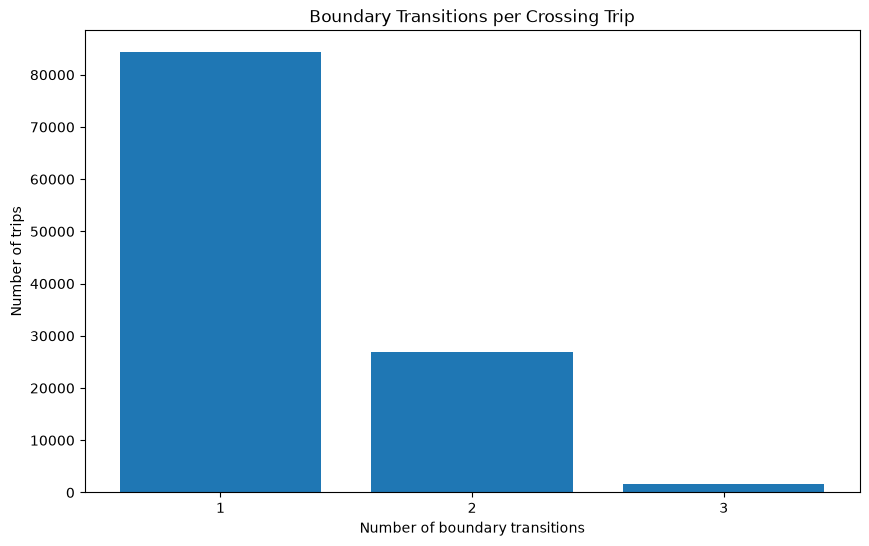

In [14]:
distribution = (
    transition_counts
    .group_by("transition_count")
    .agg(
        pl.len().alias("trip_count")
    )
    .sort("transition_count")
)

plt.figure(figsize=(10, 6))
plt.bar(
    distribution["transition_count"].to_list(),
    distribution["trip_count"].to_list(),
)
plt.xlabel("Number of boundary transitions")
plt.ylabel("Number of trips")
plt.title("Boundary Transitions per Crossing Trip")
plt.xticks(distribution["transition_count"].to_list())
plt.show()

In [15]:
three_transition_trips = (
    transition_counts
    .filter(
        pl.col("transition_count") == 3
    )
)

three_transition_trips

trip_id,transition_count
str,u32
""".ojp-91-12-C.1.TA.1.j26""",3
""".ojp-91-12-C.1.TA.10.j26""",3
""".ojp-91-12-C.1.TA.100.j26""",3
""".ojp-91-12-C.1.TA.101.j26""",3
""".ojp-91-12-C.1.TA.102.j26""",3
…,…
""".ojp-92-N10.1.TA.95.j26""",3
""".ojp-92-N10.1.TA.96.j26""",3
""".ojp-92-N10.1.TA.97.j26""",3


In [16]:
example_trip_id = (
    three_transition_trips
    .get_column("trip_id")
    .first()
)

example_trip_id

'.ojp-91-12-C.1.TA.1.j26'

In [17]:
example_trip = (
    crossing_sequence
    .filter(
        pl.col("trip_id") == example_trip_id
    )
    .select([
        "trip_id",
        "stop_sequence",
        "stop_id",
        "is_in_zurich",
    ])
    .collect()
    .join(
        bronze_stops
        .select([
            "stop_id",
            "stop_name",
            "stop_lat",
            "stop_lon",
        ])
        .collect(),
        on="stop_id",
        how="left",
    )
    .sort("stop_sequence")
)

/tmp/ipykernel_37197/2898561335.py:12: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .collect()


In [18]:
example_trip = example_trip.with_columns(
    (
        pl.col("is_in_zurich")
        != pl.col("is_in_zurich").shift(1)
    )
    .fill_null(False)
    .alias("is_transition_edge")
)

In [19]:
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)
pl.Config.set_fmt_str_lengths(100)

example_trip

trip_id,stop_sequence,stop_id,is_in_zurich,stop_name,stop_lat,stop_lon,is_transition_edge
str,i64,str,bool,str,str,str,bool
""".ojp-91-12-C.1.TA.1.j26""",1,"""ch:1:sloid:91382::1""",true,"""Zürich, Sternen Oerlikon""","""47.40996245""","""8.54623924""",false
""".ojp-91-12-C.1.TA.1.j26""",2,"""ch:1:sloid:91063::3""",true,"""Zürich Oerlikon, Bahnhof Ost""","""47.41358561""","""8.54640093""",false
""".ojp-91-12-C.1.TA.1.j26""",3,"""ch:1:sloid:91256::1""",true,"""Zürich, Leutschenbach""","""47.41484393""","""8.55151235""",false
""".ojp-91-12-C.1.TA.1.j26""",4,"""ch:1:sloid:91294::1""",true,"""Zürich, Oerlikerhus""","""47.41780420""","""8.55410848""",false
""".ojp-91-12-C.1.TA.1.j26""",5,"""ch:1:sloid:91830::1""",false,"""Glattpark, Glattpark""","""47.41996200""","""8.55742326""",true
""".ojp-91-12-C.1.TA.1.j26""",6,"""ch:1:sloid:91128::1""",true,"""Zürich, Fernsehstudio""","""47.41808381""","""8.56193281""",true
""".ojp-91-12-C.1.TA.1.j26""",7,"""ch:1:sloid:91049::2""",true,"""Zürich, Auzelg""","""47.41709302""","""8.56908340""",false
""".ojp-91-12-C.1.TA.1.j26""",8,"""ch:1:sloid:90889::0""",false,"""Wallisellen, Herti""","""47.41642438""","""8.57930622""",true
""".ojp-91-12-C.1.TA.1.j26""",9,"""ch:1:sloid:90881::0""",false,"""Wallisellen, Belair""","""47.41344579""","""8.58489374""",false


## Classifying Stops into 3 types

1. `internal`: stop exists inside the Current Zurich scope
2. `boundary`: stop is outsode Zurich scope but directly adjacent to an internal stop on a crossing trip
3. `excluded`: everything else

In [26]:
stop_scope = (
    bronze_stops
    .select([
        "stop_id",
        "stop_name",
        "stop_lat",
        "stop_lon",
    ])
    .join(
        zurich_stop_ids
        .with_columns(
            pl.lit(True).alias("is_in_zurich")
        ),
        on="stop_id",
        how="left",
    )
    .with_columns(
        pl.col("is_in_zurich").fill_null(False)
    )
)

In [27]:
stop_boundary_flags = (
    stop_adjacency
    .join(
        stop_scope
        .select([
            "stop_id",
            "is_in_zurich",
        ])
        .rename({
            "stop_id": "previous_stop_id",
            "is_in_zurich": "previous_is_in_zurich",
        }),
        on="previous_stop_id",
        how="left",
    )
    .join(
        stop_scope
        .select([
            "stop_id",
            "is_in_zurich",
        ])
        .rename({
            "stop_id": "next_stop_id",
            "is_in_zurich": "next_is_in_zurich",
        }),
        on="next_stop_id",
        how="left",
    )
    .with_columns(
        pl.col("previous_is_in_zurich").fill_null(False),
        pl.col("next_is_in_zurich").fill_null(False),
    )
    .group_by("stop_id")
    .agg(
        (
            pl.col("previous_is_in_zurich")
            | pl.col("next_is_in_zurich")
        )
        .any()
        .alias("touches_zurich"),
    )
)

In [28]:
classified_stops = (
    stop_scope
    .join(
        stop_boundary_flags,
        on="stop_id",
        how="left",
    )
    .with_columns(
        pl.when(pl.col("is_in_zurich"))
        .then(pl.lit("internal"))
        .when(pl.col("touches_zurich").fill_null(False))
        .then(pl.lit("boundary"))
        .otherwise(pl.lit("excluded"))
        .alias("node_type")
    )
)

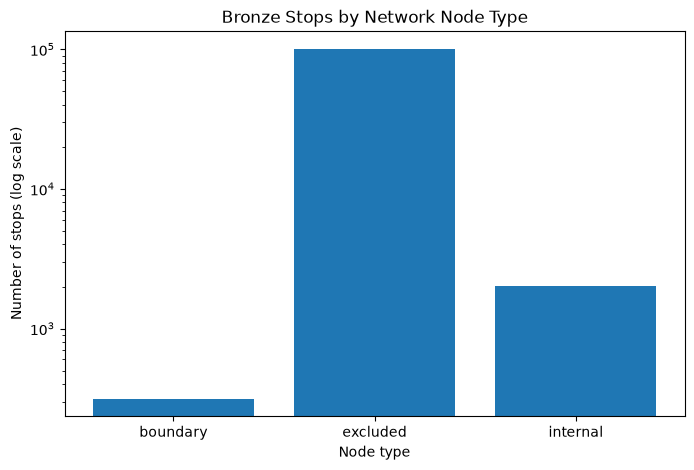

In [33]:
node_distribution = (
    classified_stops
    .group_by("node_type")
    .len()
    .sort("node_type")
    .collect()
)

plt.figure(figsize=(8, 5))

plt.bar(
    node_distribution["node_type"].to_list(),
    node_distribution["len"].to_list(),
)

plt.yscale("log")

plt.xlabel("Node type")
plt.ylabel("Number of stops (log scale)")
plt.title("Bronze Stops by Network Node Type")

plt.show()